# Smart MCQ Solver Challenge
**Roll:** 23f2003665

Predict the top-3 most likely correct answers from 5 MCQ options.
**Metric:** MAP@3 (Mean Average Precision at 3)

| Slot | Model | Kaggle MAP@3 |
|---|---|---|
| From Scratch | TextCNN | 0.74522 |
| Pretrained | DistilBERT Cross-Encoder | 0.75561 |
| Additional | TF-IDF + Logistic Regression | 0.75103 |


## Section 0 — Common Setup
Shared imports, data loading, and utility functions used across all models.


In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib
import wandb
from kaggle_secrets import UserSecretsClient
from transformers import AutoTokenizer,AutoModelForSequenceClassification, TrainingArguments,Trainer
from datasets import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OPTIONS = ['A', 'B', 'C', 'D', 'E']
SAVED_MODELS_PATH = '/kaggle/input/datasets/nitesh0602/saved-models-genai-t2'

print('Device:', device)


Device: cuda


In [2]:
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [3]:
secret = UserSecretsClient().get_secret('GENAI_T2_2026')
wandb.login(key=secret)
print('WandB ready')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [3]:
def map_at3(prediction,correct):  #function to calculate MAP@3 score
  score = 0
  for pred, x in zip(prediction, correct):
    if x in pred:
      k = pred.index(x) + 1
      score += 1/k
  return round(score/len(correct) ,4)

#### What this utility does
`map_at3()` gives a question score of **1**, **1/2**, **1/3**, or **0** depending on where the correct option appears in the top three. The final MAP@3 is the average across questions.

In [4]:
import re

def text_clean(text):
  lower_text = text.lower()
  simple_text = re.sub(r'[^a-z0-9\s]', '', lower_text)
  cleaned_text = re.sub(r'\s+', ' ', simple_text)
  return cleaned_text

---
## Section 1 — Exploratory Data Analysis

In [3]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (2000, 8)
Test: (500, 7)


In [4]:
print(f"Missing values in train:\n{train.isnull().sum()}\n")

print(f"Missing values in test:\n{test.isnull().sum()}")

Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [5]:
percentage = train['answer'].value_counts(normalize = True, ascending = False)*100

print(f"Distribution of correct answers:\n{percentage}")

Distribution of correct answers:
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64


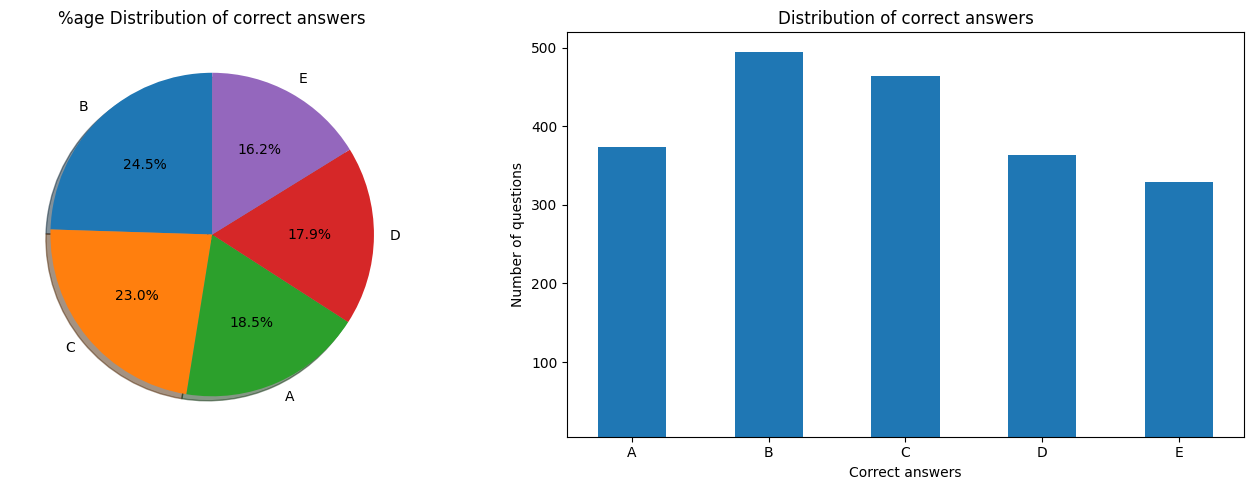

In [6]:
fig ,axes = plt.subplots(1,2 ,figsize = (14,5))

axes[0].pie(percentage, labels = percentage.index, autopct = '%1.1f%%' , shadow = True, startangle = 90)
axes[0].set_title('%age Distribution of correct answers')

#df used for bar chart
value = train['answer'].value_counts().sort_index()

axes[1].bar(value.index, value,width= 0.5, bottom = 5)
axes[1].set_title('Distribution of correct answers')
axes[1].set_xlabel('Correct answers')
axes[1].set_ylabel('Number of questions')

plt.tight_layout()
plt.show()

In [7]:
train['prompt_len'] = train['prompt'].str.len()

prompt_len_dis = train['prompt_len'].describe()
print(f"Prompt length distribution:\n{prompt_len_dis}")

Prompt length distribution:
count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64


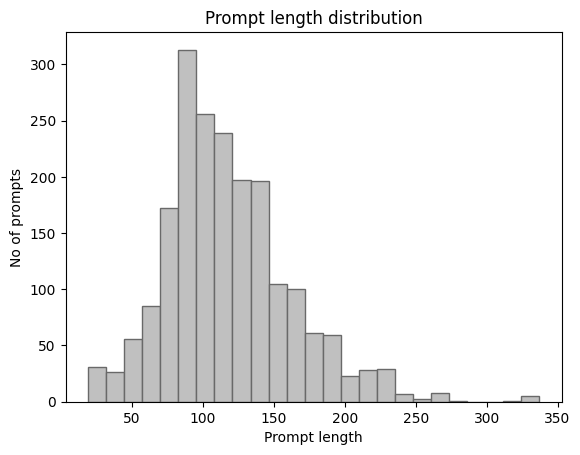

In [8]:
plt.hist(train['prompt_len'], bins = 25, edgecolor = 'dimgrey', color = 'silver',)
plt.title('Prompt length distribution')
plt.xlabel('Prompt length')
plt.ylabel('No of prompts')
plt.show()

In [9]:
#Duplicate prompts in train dataset
dup_count = train.duplicated(subset=['prompt']).sum()
print(f"Duplicate prompt rows in train: {dup_count}")
print(f"Unique prompts: {train['prompt'].nunique()} out of {len(train)}")

Duplicate prompt rows in train: 242
Unique prompts: 1758 out of 2000


In [10]:
# Find overlapping prompts between train and test
train['prompt_clean'] = train['prompt'].str.lower().str.strip()
test['prompt_clean'] = test['prompt'].str.lower().str.strip()

train_prompts = set(train['prompt_clean'])
test_prompts = set(test['prompt_clean'])
overlap = train_prompts.intersection(test_prompts)

print(f'Train unique prompts : {len(train_prompts)}')
print(f'Test unique prompts : {len(test_prompts)}')
print(f'Overlapping prompts: {len(overlap)}')
print(f'Overlap percentage: {len(overlap)/len(test_prompts)*100:.1f}%')

Train unique prompts : 1758
Test unique prompts : 492
Overlapping prompts: 267
Overlap percentage: 54.3%


#### EDA takeaway
The key issue is **duplicate content**: 242 duplicate prompt rows exist in training and 267 unique prompts overlap between train and test. This also means a normal random validation split can be overly optimistic.

---
## Section 2 - Baseline MAP@3 calculation for train dataset

In [12]:
# for top 3 answers

top3_ans = train['answer'].value_counts().index[0:3].tolist()
print(f"Top 3 most frequent answers: {top3_ans}")

top3_pred = [top3_ans] * len(train)

correct_ans = train['answer'].tolist()
print("Baseline MAP@3 for top 3 most frequent answers:",map_at3(top3_pred, correct_ans))

Top 3 most frequent answers: ['B', 'C', 'A']
Baseline MAP@3 for top 3 most frequent answers: 0.4213


In [13]:
# for random 3 answers
random.seed(42)
options = ['A', 'B','C','D','E']

random_pred = [random.sample(options , 3) for i in range(len(train))]  #list with elements as list of 3 random elements

print("Baseline MAP@3 for top 3 random answers:",map_at3(random_pred, correct_ans))

Baseline MAP@3 for top 3 random answers: 0.3675


#### Baseline takeaway
These are the **reference baselines** used in this project:
- Most-frequent top-3 (`B C A`): **0.4213 MAP@3**
- Random top-3: **0.3675 MAP@3**

The trained models should clearly outperform these simple strategies.

---
## Section 3 — Model 1: TF-IDF + Logistic Regression

**Approach:** Build TF-IDF vectors for each (prompt, option) pair → train Logistic Regression to score each pair → rank top 3

**Training config:**
- TF-IDF: ngram_range=(1,3), sublinear_tf=True, max_features=50000
- LR: max_iter=5000, class_weight='balanced', random_state=42
- Train/val split: 80/20

**Kaggle MAP@3: 0.75103**

### Text cleaning methods:
Creating a function to convert the raw text data into cleaner text form by:

1. Lowercasing the texts
2. Removing any kind of special characters
3. Reducing multiple white spaces(if there) into one.

In [9]:
import re

def text_clean(text):
  lower_text = text.lower()
  simple_text = re.sub(r'[^a-z0-9\s]', '', lower_text)
  cleaned_text = re.sub(r'\s+', ' ', simple_text)
  return cleaned_text

In [10]:
#applying function to all the columns in both train and test
cols = ['prompt' , 'A', 'B' , 'C' , 'D' , 'E']

for col in cols:
    train[col +'_clean'] = train[col].apply(text_clean)
    test[col +'_clean'] = test[col].apply(text_clean)

### Applying train test split on the dataset

In [9]:
from sklearn.model_selection import train_test_split

x = train.copy()
x_train, x_test = train_test_split(x, test_size=0.2, random_state=42)


In [11]:
#function to build prompt and option pairs

def build_pairs(df):
    rows = []
    for i in df.index:
        prompt = df.loc[i, 'prompt_clean']
        options = ['A', 'B', 'C', 'D', 'E']
        for opt in options:
            text = prompt + ' ' + df.loc[i, f'{opt}_clean']
            label = 0
            if df.loc[i, 'answer'] == opt:
                label = 1

            rows.append({'id': df.loc[i, 'id'],
                         'option': opt,
                         'text': text,
                         'label': label})
    return pd.DataFrame(rows)

train_pairs = build_pairs(x_train)
val_pairs = build_pairs(x_test)

print(train_pairs.shape, val_pairs.shape)

(8000, 4) (2000, 4)


#### Why prompt-option pairs for TF-IDF + LR?
One MCQ becomes five binary examples. The correct pair gets label `1` and the other four get `0`. Logistic Regression then gives a correctness score for each option, which can be ranked.

In [12]:
train_pairs.iloc[0:5]

,id,option,text,label
0,969,A,pick the best possible answer what is the prop...,1
1,969,B,pick the best possible answer what is the prop...,0
2,969,C,pick the best possible answer what is the prop...,0
3,969,D,pick the best possible answer what is the prop...,0
4,969,E,pick the best possible answer what is the prop...,0


In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(ngram_range=(1,3),
#                         sublinear_tf=True,
#                         max_features=50000)
# x_train_tfidf = tfidf.fit_transform(train_pairs['text'])
# x_test_tfidf = tfidf.transform(val_pairs['text'])

# y_train_labels = train_pairs['label']
# y_test_labels = val_pairs['label']

# from sklearn.linear_model import LogisticRegression
# lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
# lr.fit(x_train_tfidf, y_train_labels)

In [5]:
# Load saved TF-IDF + Logistic Regression models
tfidf = joblib.load(SAVED_MODELS_PATH + '/tfidf.pkl')
lr = joblib.load(SAVED_MODELS_PATH + '/tfidf_lr_model.pkl')

# Transform validation pairs using the already-fitted TF-IDF vectorizer
x_test_tfidf = tfidf.transform(val_pairs['text'])


#### Why load saved models?
The TF-IDF vectorizer and Logistic Regression model were already trained. Loading the saved objects avoids retraining and keeps the same learned TF-IDF feature mapping for validation and test data.

In [17]:
val_pairs['prob'] = lr.predict_proba(x_test_tfidf)[:, 1]

def get_top3_predictions(pairs_df):
    predictions = []
    qids = []
    for qid, group in pairs_df.groupby('id'):
        top3 = group.sort_values('prob', ascending=False)['option'].tolist()[:3]
        predictions.append(top3)
        qids.append(qid)
    return predictions, qids

val_top3, val_qids = get_top3_predictions(val_pairs)
actual_answers = x_test.set_index('id').loc[val_qids, 'answer'].tolist()

score = map_at3(val_top3, actual_answers)
print("TF-IDF + Logistic Regression MAP@3:", score)

TF-IDF + Logistic Regression MAP@3: 0.9938


In [18]:
val_pairs.iloc[:10]

,id,option,text,label,prob
0,1861,A,select the most accurate option what is the pr...,0,0.275765
1,1861,B,select the most accurate option what is the pr...,0,0.236268
2,1861,C,select the most accurate option what is the pr...,0,0.418122
3,1861,D,select the most accurate option what is the pr...,1,0.648659
4,1861,E,select the most accurate option what is the pr...,0,0.434574
5,354,A,pick the best possible answer what is the most...,0,0.259075
6,354,B,pick the best possible answer what is the most...,0,0.330388
7,354,C,pick the best possible answer what is the most...,0,0.234732
8,354,D,pick the best possible answer what is the most...,0,0.298763
9,354,E,pick the best possible answer what is the most...,1,0.702472


### Generate Kaggle Submission

In [6]:
def build_test_pairs(df): #Creates one row per (question, option) pair for the test set.
    rows = []
    for i in df.index:
        prompt =df.loc[i,'prompt_clean']
        
        for opt in ['A','B','C','D','E']:
            text= prompt + ' ' + df.loc[i, f'{opt}_clean']
            rows.append({'id': df.loc[i, 'id'], 
                         'option': opt, 
                         'text': text})
            
    return pd.DataFrame(rows)
    

In [11]:
test_pairs = build_test_pairs(test)
test_features = tfidf.transform(test_pairs["text"])

probabilities = lr.predict_proba(test_features)[:, 1]

test_pairs["prob"] = probabilities

In [13]:
predictions = []

for question_id, group in test_pairs.groupby("id"):
    sorted_group = group.sort_values("prob",ascending=False)

    top3_options = sorted_group["option"].tolist()[:3]

    top3_prediction = " ".join(top3_options)

    predictions.append(top3_prediction)

In [14]:
submission = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
submission["Prediction"] = predictions

submission.to_csv("/kaggle/working/submission.csv",index=False)

print("Submission shape:", submission.shape)
submission.head()

Submission shape: (500, 2)


,ID,Prediction
0,1,A E B
1,2,B C E
2,3,B E D
3,4,E C D
4,5,C A D


#### TF-IDF + LR result
The local validation MAP@3 is very high (**0.9938**), while the Kaggle score is **0.75103**. The gap is a warning that the local split is affected by repeated/duplicate prompt content.

**Kaggle score :** 0.75103

---
## Section 4 — Model 2: TextCNN (From Scratch)

**Architecture:** Embedding → Conv1D → ReLU → Global Max Pooling → Linear (5 logits)

**Training config:**
- Embedding dim: 64 | Filters: 64 | Kernel: 3
- Input: prompt + all 5 options concatenated | max_len: 160
- Batch size: 32
- Loss: CrossEntropyLoss (5-class)
- Optimizer: Adam | Learning rate: 1e-3
- Epochs: 10

**Kaggle MAP@3: 0.74522**


In [3]:
MAX_LEN = 160
BATCH_SIZE = 32
EMBED_DIM = 64
NUM_FILTERS = 64
KERNEL_SIZE = 3

In [4]:
def clean(t):
    return re.sub(r'[^a-z0-9 ]', '', str(t).lower())

all_text = ' '.join(
    train['prompt'].apply(clean).tolist() +
    train['A'].apply(clean).tolist() +
    train['B'].apply(clean).tolist() +
    train['C'].apply(clean).tolist() +
    train['D'].apply(clean).tolist() +
    train['E'].apply(clean).tolist()
)

# sorted() keeps the word-to-index mapping reproducible
vocab = ['<PAD>', '<UNK>'] + sorted(set(all_text.split()))
w2i = {w: i for i, w in enumerate(vocab)}

def encode(text, maxlen=MAX_LEN):
    words = clean(text).split()
    ids = [w2i.get(w, 1) for w in words]

    ids = ids[:maxlen]                         # truncate
    ids = ids + [0] * (maxlen - len(ids))     # pad
    return ids

print('Vocab size:', len(vocab))


Vocab size: 3084


#### TextCNN input preparation
TextCNN uses a **custom word-level vocabulary**. `<PAD>` is index 0 and `<UNK>` is index 1. Every question is encoded to a fixed length of **160 tokens**.

In [5]:
#encode prompt + all 5 options concatenated
def encode_row(row, maxlen=MAX_LEN):
    text = row['prompt'] + ' ' + ' '.join(
        [str(row[o]) for o in OPTIONS]
    )
    return encode(text, maxlen)

# Encode every training row
encoded_rows = []

for _, row in train.iterrows():
    encoded_row = encode_row(row)
    encoded_rows.append(encoded_row)

X = torch.tensor(encoded_rows, dtype=torch.long)


# Convert answers A–E into numbers 0–4
answer_labels = []

for answer in train["answer"]:
    label = ord(answer) - ord("A")
    answer_labels.append(label)

y = torch.tensor(answer_labels, dtype=torch.long)

print('X:', X.shape, '| y:', y.shape)

X: torch.Size([2000, 160]) | y: torch.Size([2000])


#### TextCNN formulation
Unlike the pairwise models, TextCNN sees **prompt + all five options together** and directly predicts one of five classes (`A-E`).

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train = X_train.to(device)
y_train = y_train.to(device)

X_val = X_val.to(device)
y_val = y_val.to(device)

print("Train:", X_train.shape, "| Val:", X_val.shape)

Train: torch.Size([1700, 160]) | Val: torch.Size([300, 160])


In [7]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.emb = nn.Embedding(vocab_size,EMBED_DIM,padding_idx=0)
        self.conv = nn.Conv1d(EMBED_DIM,NUM_FILTERS,kernel_size=KERNEL_SIZE)
        self.fc = nn.Linear(NUM_FILTERS, 5)

    def forward(self, x):
        x = self.emb(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv(x))
        x = F.max_pool1d(x, x.shape[2]).squeeze(2)
        return self.fc(x)

model = TextCNN(len(vocab)).to(device)
print(model)

TextCNN(
  (emb): Embedding(3084, 64, padding_idx=0)
  (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


#### TextCNN architecture
`Embedding → Conv1D → ReLU → Global Max Pooling → Linear(5)`

Conv1D learns local phrase patterns; global max pooling keeps the strongest activation from each filter; the final layer produces five raw logits.

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [9]:
def compute_map3(logits, labels):
    # Convert logits to probabilities
    probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Get top 3 predicted class indices for every question
    predictions = []

    for prob in probs:
        top3 = prob.argsort()[::-1][:3].tolist()
        predictions.append(top3)

    # Convert actual labels tensor to Python list
    correct = labels.cpu().numpy().tolist()
    
    return map_at3(predictions, correct)

In [ ]:
# secret = UserSecretsClient().get_secret('GENAI_T2_2026')
# wandb.login(key=secret)
# wandb.init(
#     project='23f2003665-t22026',
#     name='textcnn-final',
#     config={
#         'vocab_size': len(vocab),
#         'embed_dim': EMBED_DIM,
#         'num_filters': NUM_FILTERS,
#         'kernel_size': KERNEL_SIZE,
#         'max_len': MAX_LEN,
#         'batch_size': BATCH_SIZE,
#         'lr': 1e-3,
#         'epochs': 10,
#     }
# )
#
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = nn.CrossEntropyLoss()
# best_map3 = 0.0
#
# for epoch in range(10):
#     model.train()
#     total_loss = 0.0
#
#     for xb, yb in train_loader:
#         xb = xb.to(device)
#         yb = yb.to(device)
#
#         optimizer.zero_grad()
#         logits = model(xb)
#         loss = criterion(logits, yb)
#         loss.backward()
#         optimizer.step()
#
#         total_loss += loss.item()
#
#     model.eval()
#     with torch.no_grad():
#         val_logits = model(X_val)
#
#     val_map3 = compute_map3(val_logits, y_val)
#     avg_loss = total_loss / len(train_loader)
#
#     if val_map3 > best_map3:
#         best_map3 = val_map3
#         torch.save(model.state_dict(), '/kaggle/working/textcnn_best.pt')
#
#     wandb.log({
#         'epoch': epoch + 1,
#         'train_loss': avg_loss,
#         'val_map3': val_map3
#     })
#
#     print(
#         f'Epoch {epoch+1} | '
#         f'Loss: {avg_loss:.4f} | '
#         f'Val MAP@3: {val_map3:.4f}'
#     )
#
# wandb.finish()
# print('Training complete. Best MAP@3:', best_map3)


Epoch 1 | Loss: 0.8894 | Val MAP@3: 0.9933

Epoch 2 | Loss: 0.4770 | Val MAP@3: 1.0000

Epoch 3 | Loss: 0.2294 | Val MAP@3: 1.0000

Epoch 4 | Loss: 0.1095 | Val MAP@3: 1.0000

Epoch 5 | Loss: 0.0606 | Val MAP@3: 1.0000

Epoch 6 | Loss: 0.0382 | Val MAP@3: 1.0000

Epoch 7 | Loss: 0.0258 | Val MAP@3: 1.0000

Epoch 8 | Loss: 0.0187 | Val MAP@3: 1.0000

Epoch 9 | Loss: 0.0142 | Val MAP@3: 1.0000

Epoch 10 | Loss: 0.0111 | Val MAP@3: 1.0000

#### TextCNN training loop
For each mini-batch: `zero_grad → forward pass → CrossEntropy loss → backward → optimizer.step`.  
Validation MAP@3 is checked after each epoch and the best checkpoint is saved.

In [13]:
model.load_state_dict(
    torch.load('/kaggle/working/textcnn_best.pt', map_location=device)
)
model.eval()

# Encode test data
X_test = torch.tensor(
    [encode_row(row) for _, row in test.iterrows()],
    dtype=torch.long
).to(device)

with torch.no_grad():
    outputs = model(X_test)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()

predictions = []

for probability in probs:
    top3_indices = probability.argsort()[::-1][:3]
    top3_options = [OPTIONS[index] for index in top3_indices]
    predictions.append(" ".join(top3_options))

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

submission = sample_submission.copy()
submission["Prediction"] = predictions
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission saved!")
submission.head()


Submission saved!


,ID,Prediction
0,1,A C B
1,2,B E C
2,3,B D A
3,4,E C B
4,5,C D E


#### TextCNN inference
Load the best trained checkpoint, generate five logits for every test question, select the top three option indices, convert them back to `A-E`, and save the submission.

**Kaggle score: 0.74522**

---
## Section 5 — Model 3: DistilBERT (Pretrained)

**Architecture:** [CLS] prompt [SEP] option [SEP] → DistilBERT(6 layers) → Linear(768→1) → score

**Training config:**
- Model: distilbert-base-uncased | max_len: 160
- LR: 2e-5
- Epochs: 10 | Batch: 16
- Best checkpoint by val_MAP@3

**Kaggle MAP@3: 0.75561**

In [1]:
!pip install transformers datasets wandb --quiet

In [2]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
import wandb

OPTIONS = ['A', 'B', 'C', 'D', 'E']
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
from kaggle_secrets import UserSecretsClient
wandb.login(key=UserSecretsClient().get_secret('GENAI_T2_2026'))

wandb.init(
    project = '23f2003665-t22026',
    name= 'distilbert-v3',
    config  = {
        'model': 'distilbert-base-uncased',
        'max_len': 160,
        'batch_size' : 16,
        'epochs' : 10,
        'lr': 2e-5,
    }
)
cfg = wandb.config

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


### DistilBERT — Load Data
Load a fresh copy of the train and test data for the DistilBERT pipeline.

In [4]:
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df= pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
print('Train:', train_df.shape, '| Test:', test_df.shape)

Train: (2000, 8) | Test: (500, 7)


In [5]:
import re

# These repeated phrases add little task-specific information
NOISE = [
    'pick the best possible answer',
    'select the most accurate option', 
    'identify the correct statement',
    'choose the correct answer',
    'determine the correct option',
    'which of the following is correct',
    'among the listed options',
    'from the following choices',
    'based on the given context',
    'carefully',
]

def clean_prompt(text):
    text = str(text).lower()
    for phrase in NOISE:
        text = text.replace(phrase, '')
    # Remove extra spaces and punctuation left behind
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to prompts
train_df['prompt'] = train_df['prompt'].apply(clean_prompt)
test_df['prompt'] = test_df['prompt'].apply(clean_prompt)

print('Noise removed from prompts.')
print('Example:', train_df['prompt'].iloc[0][:100])

Noise removed from prompts.
Example: what is martin heideggers view on the relationship between time and human existence


#### DistilBERT-specific preprocessing
Only the prompt receives this extra cleaning. The goal is to remove repeated instruction wording and keep the actual question content before pairwise tokenization.

### DistilBERT — Split and Build Pairs
Split original question rows first, then expand each question into five `(prompt, option)` pairs.  
This keeps all five options of one row in the same split, although duplicate prompt text under different rows can still cross the split.

In [6]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

# Convert each question into 5 prompt-option pairs
def build_pairs(df):
    pairs = []

    for _, row in df.iterrows():
        for option in OPTIONS:
            pair = {
                'text1': str(row['prompt']),
                'text2': str(row[option])
            }

            # Train/validation data contains the answer column.
            # Test data does not, so no label is added there.
            if 'answer' in df.columns:
                pair['label'] = 1.0 if row['answer'] == option else 0.0

            pairs.append(pair)

    return pairs

train_pairs = build_pairs(train_data)
val_pairs = build_pairs(val_data)
test_pairs = build_pairs(test_df)

print('Train pairs:', len(train_pairs), '| Val pairs:', len(val_pairs))


Train pairs: 9000 | Val pairs: 1000


#### DistilBERT pairwise formulation
Each question becomes five `(prompt, option)` inputs. Correct pair target = `1.0`; incorrect pair target = `0.0`. Test pairs have no label.

### DistilBERT — Tokenization
Convert the pair lists into Hugging Face `Dataset` objects and tokenize the prompt and option together.

In [7]:
MODEL_NAME = cfg.model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text1'],
        batch['text2'],
        max_length=cfg.max_len,
        padding='max_length',
        truncation=True
    )

# Convert pair lists to Hugging Face datasets and tokenize them
train_dataset = Dataset.from_list(train_pairs).map(tokenize, batched=True)
val_dataset = Dataset.from_list(val_pairs).map(tokenize, batched=True)
test_dataset = Dataset.from_list(test_pairs).map(tokenize, batched=True)

# Return the required columns as PyTorch tensors
train_dataset.set_format('torch',columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch',columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch',columns=['input_ids', 'attention_mask'])

print('Tokenization done.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Tokenization done.


#### Tokenizer output
The pretrained tokenizer produces:
- `input_ids` — subword token IDs
- `attention_mask` — `1` for real tokens and `0` for padding

Pairs are padded/truncated to **160 tokenizer positions**.

### DistilBERT — Load Pretrained Model
Load `distilbert-base-uncased` with one output score per prompt-option pair.

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=1, problem_type='regression'
).to(device)
print('Model loaded:', MODEL_NAME)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased


### DistilBERT — Validation MAP@3
Group every five pair scores back into one MCQ, rank the five options, and calculate MAP@3.

In [9]:
def compute_metrics(eval_pred):
    logits, _ = eval_pred

    scores = logits.reshape(-1, 5)

    predictions = []
    for score in scores:
        top3 = np.argsort(score)[::-1][:3].tolist()
        predictions.append(top3)

    correct = []
    for answer in val_data["answer"]:
        correct.append(OPTIONS.index(answer))

    return {"val_map3": map_at3(predictions, correct)}

#### Why reshape to `(-1, 5)`?
DistilBERT predicts one score for each pair. Since every original question creates exactly five pairs in `A-E` order, reshaping groups those five scores back into one MCQ for ranking.

### DistilBERT — Training
`Trainer` handles batching, forward passes, MSE loss, backpropagation, evaluation and checkpoint selection.  
The block is kept commented so training is not repeated during the presentation.

In [ ]:
# args = TrainingArguments(
#     output_dir='/kaggle/working/',
#     num_train_epochs=cfg.epochs,
#     per_device_train_batch_size=cfg.batch_size,
#     per_device_eval_batch_size=cfg.batch_size,
#     learning_rate=cfg.lr,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     metric_for_best_model='val_map3',
#     greater_is_better=True,
#     fp16=False,
#     report_to='wandb',
# )
#
# trainer = Trainer(
#     model=model,
#     args=args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics,
# )
#
# trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Val Map3
1,No log,0.168032,0.947500
2,0.226026,0.070653,0.977500
3,0.226026,0.036195,0.992500
4,0.067839,0.026044,0.987500
5,0.067839,0.013514,0.987500
6,0.029882,0.012213,0.995000
7,0.029882,0.008059,0.995000
8,0.012981,0.007311,0.995000
9,0.008905,0.006129,0.995000
10,0.008905,0.005810,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2820, training_loss=0.06208500507030081, metrics={'train_runtime': 806.7133, 'train_samples_per_second': 111.564, 'train_steps_per_second': 3.496, 'total_flos': 3725579145600000.0, 'train_loss': 0.06208500507030081, 'epoch': 10.0})

In [ ]:
# Load saved DistilBERT model + tokenizer
model = AutoModelForSequenceClassification.from_pretrained(SAVED_MODELS_PATH + '/distilbert_final/').to(device)
tokenizer = AutoTokenizer.from_pretrained(SAVED_MODELS_PATH + '/distilbert_final/')

trainer = Trainer(model=model)

#### Saved DistilBERT checkpoint
The fine-tuned model is loaded from the saved checkpoint for inference. A new `Trainer(model=model)` is enough here because no further training is required.

### DistilBERT — Test Inference and Submission
Predict one raw score per prompt-option pair, reshape to five scores per question, rank them, and write the top three option letters to the sample submission.

In [11]:
preds = trainer.predict(test_dataset)

# Group the five option scores for each original question
scores = preds.predictions.reshape(-1, 5)

predictions = []

for score in scores:
    top3_indices = np.argsort(score)[::-1][:3]

    top3 = []
    for index in top3_indices:
        top3.append(OPTIONS[index])

    predictions.append(" ".join(top3))

# Load a fresh sample submission so this section is self-contained
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

submission = sample_submission.copy()
submission["Prediction"] = predictions
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission saved!")
submission.head()


Submission saved!


,id,Prediction
0,1,A C D
1,2,B D C
2,3,B D A
3,4,E B C
4,5,C E D


#### DistilBERT inference
Raw regression scores are sorted directly. The top three option indices are converted to letters and written into a fresh copy of the sample submission.

In [12]:
wandb.finish()

eval/loss,█▄▂▂▁▁▁▁▁▁
eval/runtime,▁▄▇███████
eval/samples_per_second,█▅▂▁▁▁▁▁▁▁
eval/steps_per_second,█▅▂▁▁▁▁▁▁▁
eval/val_map3,▁▅▇▆▆▇▇▇▇█
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
train/epoch,▁▂▂▃▃▃▄▄▅▆▆▆▇▇██
train/global_step,▁▂▂▃▃▃▄▄▅▆▆▆▇▇███
+3,...


---
## Section 6 — Results Summary

### Reference baselines from EDA

| Baseline | MAP@3 |
|---|---:|
| Top-3 most frequent answers (B, C, A) | **0.4213** |
| Random top-3 (seed = 42) | **0.3675** |

### Final model results

| Slot | Model | Kaggle MAP@3 |
|---|---|---:|
| From Scratch | TextCNN | **0.74522** |
| Pretrained | DistilBERT-base-uncased | **0.75561** |
| Additional | TF-IDF + Logistic Regression | **0.75103** |

### Main takeaway
- All three final models perform well above the simple reference baselines.
- Local validation MAP@3 can be much higher than Kaggle MAP@3 because duplicate prompt text can occur across a simple train/validation split.
